# 04 - Hyperparameter Optimization

## Dataset: hourlySteps_clean.csv

### Programación para la Ciencia de Datos

## Objetivo
Optimizar hiperparámetros de modelos supervisados utilizando `GridSearchCV` y `RandomizedSearchCV`.

Este notebook busca mejorar el rendimiento de los modelos entrenados previamente, comparando resultados antes y después de la optimización.

## Criterios cubiertos
- Optimización con GridSearchCV
- Optimización con RandomizedSearchCV
- Comparación baseline vs modelo optimizado
- Uso de validación cruzada
- Evaluación con F1-Score
- Interpretación técnica del impacto

In [1]:
# ========================================
# LIBRERÍAS
# ========================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold
)

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

RANDOM_STATE = 42

sns.set_style("whitegrid")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
# ========================================
# CARGA DEL DATASET
# ========================================

df = pd.read_csv("hourlySteps_clean.csv")

print("Dimensiones del dataset:")
print(df.shape)

df.head()

Dimensiones del dataset:
(21273, 7)


,Id,ActivityHour,StepTotal,Hora,Dia,FinDeSemana,StepTotal_scaled
0,1.503960e+09,2016-03-12 00:00:00,0.0,0,Saturday,1,-0.428148
1,1.503960e+09,2016-03-12 01:00:00,0.0,1,Saturday,1,-0.428148
2,1.503960e+09,2016-03-12 02:00:00,0.0,2,Saturday,1,-0.428148
3,1.503960e+09,2016-03-12 03:00:00,0.0,3,Saturday,1,-0.428148
4,1.503960e+09,2016-03-12 04:00:00,0.0,4,Saturday,1,-0.428148


# Creación de Variable Objetivo

Se utiliza `StepTotal` para clasificar los registros en tres niveles de actividad física.

In [3]:
# ========================================
# VARIABLE OBJETIVO
# ========================================

def classify_activity(steps):

    if steps < 100:
        return "Low Activity"

    elif steps < 1000:
        return "Medium Activity"

    else:
        return "High Activity"

df["ActivityLevel"] = df["StepTotal"].apply(classify_activity)

df["ActivityLevel"].value_counts()

,count
ActivityLevel,
Low Activity,13060
Medium Activity,6569
High Activity,1644


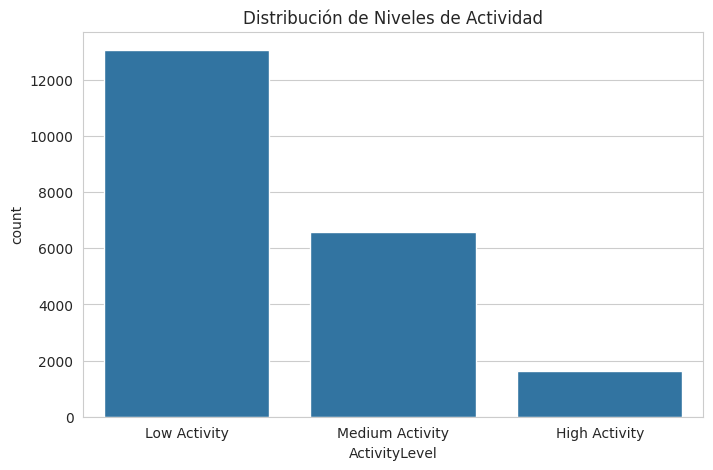

In [4]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="ActivityLevel"
)

plt.title("Distribución de Niveles de Actividad")

plt.show()

# Preparación de Variables

In [5]:
# ========================================
# FEATURES Y TARGET
# ========================================

features = [
    "Hora",
    "FinDeSemana",
    "StepTotal_scaled"
]

X = df[features]

y = df["ActivityLevel"]

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print("Clases codificadas:")
print(encoder.classes_)

Clases codificadas:
['High Activity' 'Low Activity' 'Medium Activity']


In [6]:
# ========================================
# DIVISIÓN TRAIN / TEST
# ========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (17018, 3)
Test: (4255, 3)


# Modelos Baseline

Se entrenan modelos iniciales sin optimización para tener una base de comparación.

In [7]:
# ========================================
# MODELOS BASELINE
# ========================================

rf_baseline = Pipeline([
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))
])

svm_baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(random_state=RANDOM_STATE))
])

rf_baseline.fit(X_train, y_train)
svm_baseline.fit(X_train, y_train)

rf_baseline_pred = rf_baseline.predict(X_test)
svm_baseline_pred = svm_baseline.predict(X_test)

baseline_results = pd.DataFrame([
    {
        "Model": "Random Forest Baseline",
        "Accuracy": accuracy_score(y_test, rf_baseline_pred),
        "Precision": precision_score(y_test, rf_baseline_pred, average="weighted"),
        "Recall": recall_score(y_test, rf_baseline_pred, average="weighted"),
        "F1-Score": f1_score(y_test, rf_baseline_pred, average="weighted")
    },
    {
        "Model": "SVM Baseline",
        "Accuracy": accuracy_score(y_test, svm_baseline_pred),
        "Precision": precision_score(y_test, svm_baseline_pred, average="weighted"),
        "Recall": recall_score(y_test, svm_baseline_pred, average="weighted"),
        "F1-Score": f1_score(y_test, svm_baseline_pred, average="weighted")
    }
])

baseline_results

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest Baseline,1.000000,1.000000,1.000000,1.000000
1,SVM Baseline,0.993655,0.993668,0.993655,0.993634


# Optimización con GridSearchCV

Se aplica `GridSearchCV` sobre Random Forest.

Este método evalúa todas las combinaciones posibles definidas en la grilla de hiperparámetros.

In [8]:
# ========================================
# GRIDSEARCHCV - RANDOM FOREST
# ========================================

rf_pipeline = Pipeline([
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))
])

rf_param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Mejores parámetros encontrados:")
print(rf_grid.best_params_)

print("\nMejor F1 promedio en validación cruzada:")
print(rf_grid.best_score_)

Mejores parámetros encontrados:
{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 50}

Mejor F1 promedio en validación cruzada:
0.9998234745313596


# Optimización con RandomizedSearchCV

Se aplica `RandomizedSearchCV` sobre SVM.

Este método prueba combinaciones aleatorias de hiperparámetros, reduciendo el costo computacional.

In [9]:
# ========================================
# RANDOMIZEDSEARCHCV - SVM
# ========================================

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(random_state=RANDOM_STATE))
])

svm_param_dist = {
    "model__C": [0.1, 1, 10, 100],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto"]
}

svm_random = RandomizedSearchCV(
    estimator=svm_pipeline,
    param_distributions=svm_param_dist,
    n_iter=8,
    cv=cv,
    scoring="f1_weighted",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

svm_random.fit(X_train, y_train)

print("Mejores parámetros encontrados:")
print(svm_random.best_params_)

print("\nMejor F1 promedio en validación cruzada:")
print(svm_random.best_score_)

Mejores parámetros encontrados:
{'model__kernel': 'linear', 'model__gamma': 'auto', 'model__C': 100}

Mejor F1 promedio en validación cruzada:
0.9987666103824191


# Evaluación de Modelos Optimizados

In [10]:
# ========================================
# MODELOS OPTIMIZADOS
# ========================================

rf_best = rf_grid.best_estimator_
svm_best = svm_random.best_estimator_

rf_best_pred = rf_best.predict(X_test)
svm_best_pred = svm_best.predict(X_test)

optimized_results = pd.DataFrame([
    {
        "Model": "Random Forest Optimized",
        "Accuracy": accuracy_score(y_test, rf_best_pred),
        "Precision": precision_score(y_test, rf_best_pred, average="weighted"),
        "Recall": recall_score(y_test, rf_best_pred, average="weighted"),
        "F1-Score": f1_score(y_test, rf_best_pred, average="weighted")
    },
    {
        "Model": "SVM Optimized",
        "Accuracy": accuracy_score(y_test, svm_best_pred),
        "Precision": precision_score(y_test, svm_best_pred, average="weighted"),
        "Recall": recall_score(y_test, svm_best_pred, average="weighted"),
        "F1-Score": f1_score(y_test, svm_best_pred, average="weighted")
    }
])

optimized_results

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest Optimized,1.000000,1.000000,1.000000,1.000000
1,SVM Optimized,0.999765,0.999765,0.999765,0.999765


# Comparación Baseline vs Optimized

In [11]:
comparison = pd.concat(
    [baseline_results, optimized_results],
    ignore_index=True
)

comparison.sort_values(
    by="F1-Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest Baseline,1.000000,1.000000,1.000000,1.000000
2,Random Forest Optimized,1.000000,1.000000,1.000000,1.000000
3,SVM Optimized,0.999765,0.999765,0.999765,0.999765
1,SVM Baseline,0.993655,0.993668,0.993655,0.993634


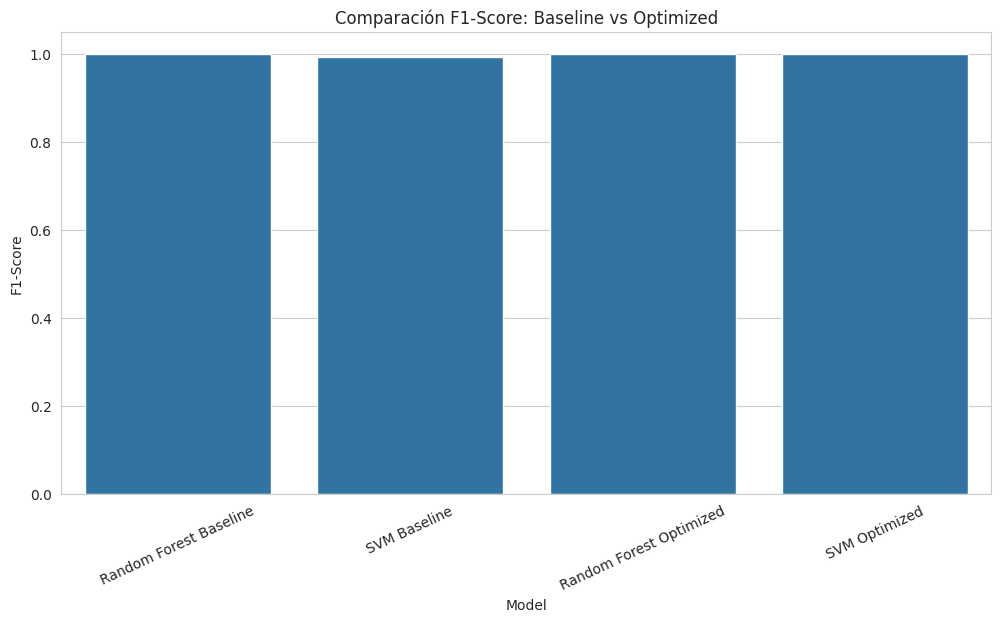

In [12]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=comparison,
    x="Model",
    y="F1-Score"
)

plt.title("Comparación F1-Score: Baseline vs Optimized")

plt.xticks(rotation=25)

plt.show()

# Matrices de Confusión Finales

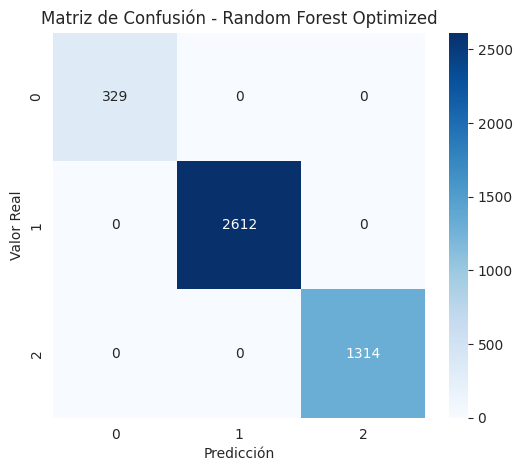

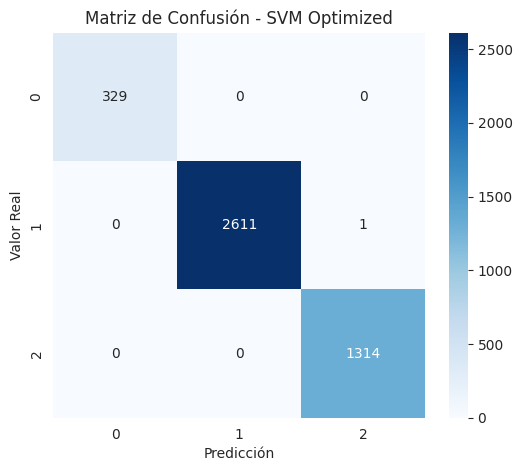

In [13]:
final_predictions = {
    "Random Forest Optimized": rf_best_pred,
    "SVM Optimized": svm_best_pred
}

for name, predictions in final_predictions.items():

    plt.figure(figsize=(6,5))

    cm = confusion_matrix(y_test, predictions)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Matriz de Confusión - {name}")

    plt.xlabel("Predicción")
    plt.ylabel("Valor Real")

    plt.show()

# Classification Reports Finales

In [14]:
for name, predictions in final_predictions.items():

    print("="*70)
    print(name)

    print(
        classification_report(
            y_test,
            predictions,
            target_names=encoder.classes_
        )
    )

Random Forest Optimized
                 precision    recall  f1-score   support

  High Activity       1.00      1.00      1.00       329
   Low Activity       1.00      1.00      1.00      2612
Medium Activity       1.00      1.00      1.00      1314

       accuracy                           1.00      4255
      macro avg       1.00      1.00      1.00      4255
   weighted avg       1.00      1.00      1.00      4255

SVM Optimized
                 precision    recall  f1-score   support

  High Activity       1.00      1.00      1.00       329
   Low Activity       1.00      1.00      1.00      2612
Medium Activity       1.00      1.00      1.00      1314

       accuracy                           1.00      4255
      macro avg       1.00      1.00      1.00      4255
   weighted avg       1.00      1.00      1.00      4255



# Análisis Técnico de Optimización

## GridSearchCV
GridSearchCV realiza una búsqueda exhaustiva sobre todas las combinaciones definidas en la grilla.  
En este notebook se aplicó a Random Forest porque este modelo posee hiperparámetros importantes como:

- `n_estimators`
- `max_depth`
- `min_samples_split`

Estos parámetros controlan la complejidad del modelo y pueden afectar directamente el overfitting o underfitting.

## RandomizedSearchCV
RandomizedSearchCV realiza una búsqueda aleatoria sobre un espacio de hiperparámetros.  
Se aplicó a SVM porque permite explorar configuraciones relevantes con menor costo computacional.

## Impacto de la Optimización
La comparación entre modelos baseline y optimizados permite observar si el ajuste de hiperparámetros mejora el rendimiento final.  
El uso de F1-Score es adecuado porque considera tanto precision como recall, entregando una visión más equilibrada que accuracy.

## Conclusión
La optimización de hiperparámetros permite seleccionar modelos más robustos, mejorar la capacidad predictiva y justificar técnicamente la elección del modelo final.